In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from DataPrep import DataPrepping

In [78]:
dataset = pd.read_csv('../Data/HouseInfo.csv')
DataPrepping(dataset)

data = dataset.iloc[:, 1:-1]
target = dataset.iloc[:, -1]

train_data, test_data, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)

In [ ]:
data.dtype()

AttributeError: 'DataFrame' object has no attribute 'dtype'

# MODEL SELECTION

## Support Vector Machine

COARSE SEARCH

In [69]:
svr = SVR()

parameters_SVR = {'kernel': ['rbf', 'sigmoid'], 'C': [0.1, 1, 10], 'gamma': [1e-3, 1e-2]}

search = GridSearchCV(svr, param_grid=parameters_SVR)

search.fit(train_data, train_target)

ValueError: 
All the 60 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\vmm\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\vmm\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vmm\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py", line 190, in fit
    X, y = self._validate_data(
           ^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vmm\AppData\Local\Programs\Pyt

FINE SEARCH

In [4]:
svr.set_params(kernel='rbf')

parameters_fine_SVR = {'C':[9, 10, 11], 'gamma': [1e-3, 2e-3, 5e-4]}

search_fine = GridSearchCV(svr, param_grid=parameters_fine_SVR)

search_fine.fit(train_data, train_target)

GridSearchCV(estimator=SVR(),
             param_grid={'C': [9, 10, 11], 'gamma': [0.001, 0.002, 0.0005]})

In [7]:
svr.set_params(C=search_fine.best_params_['C'], gamma=search_fine.best_params_['gamma'])

scores = cross_val_score(svr, train_data, train_target, cv=5, scoring='r2')
print(scores)
print(np.mean(scores))
print(np.std(scores))

[-0.04620033 -0.11409101 -0.01557072 -0.03276817 -0.054281  ]
-0.05258224448161482
0.03343469304856249


## XGBoost

COARSE SEARCH

In [8]:
xgb = XGBRegressor(n_jobs=-1)

parameters_XGB = {'n_estimators': [100,500,1000], 'max_depth': [3, 7, 10], 'learning_rate': [1e-2, 1e-3], 'gamma': [0, 0.1, 0.3, 1]}

search = GridSearchCV(xgb, param_grid=parameters_XGB, verbose=1, n_jobs=-1)

search.fit(train_data, train_target)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    lear...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1, 0.3, 1],
                         'learning_rate': [0.01, 0.001],
                         'max_depth': [3, 7, 10],
                         'n_estimators': [100, 500, 1000]},
             verbose=1)

FINE SEARCH

In [9]:
xgb.set_params(gamma=search.best_params_['gamma'],max_depth=search.best_params_['max_depth'])

fine_parameters_XGB = {'n_estimators':[1000, 1500, 2000], 'learning_rate':[0.01, 0.05, 0.07]}

fine_search = GridSearchCV(xgb, param_grid=fine_parameters_XGB, verbose=1, n_jobs=-1)

fine_search.fit(train_data, train_target)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=0, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=3, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.07],
                         'n_estimators': [1000, 1500, 2000]},
             verbose=1)

In [10]:
xgb.set_params(n_estimators=fine_search.best_params_['n_estimators'], learning_rate=fine_search.best_params_['learning_rate'])

scores = cross_val_score(xgb, train_data, train_target, cv=5, scoring='r2')
print(scores)
print(np.mean(scores))
print(np.std(scores))

[0.83507907 0.77013379 0.87695813 0.88485068 0.91042703]
0.8554897427558898
0.04907809261123959


## Random Forest

Coarse Search

In [11]:
rand_f = RandomForestRegressor(n_jobs=-1)

parameters_RandF = {'n_estimators': [100,200,500], 'max_depth': [None, 10, 20, 30], 'max_features': ['sqrt', 'log2', 0.5], 'min_samples_split': [2, 5, 10, 20], 'bootstrap':[True, False]}

search = GridSearchCV(rand_f, param_grid=parameters_RandF, n_jobs=-1)

search.fit(train_data, train_target)

GridSearchCV(estimator=RandomForestRegressor(n_jobs=-1), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2', 0.5],
                         'min_samples_split': [2, 5, 10, 20],
                         'n_estimators': [100, 200, 500]})

Fine search

In [12]:
rand_f.set_params(bootstrap=search.best_params_['bootstrap'], max_features=search.best_params_['max_features'], min_samples_split=search.best_params_['min_samples_split'])

fine_parameteres_RandF = {'max_depth':[30, 40, 50], 'n_estimators':[50, 75, 100]}

fine_search = GridSearchCV(rand_f, param_grid=fine_parameteres_RandF, n_jobs=-1)

fine_search.fit(train_data, train_target)

GridSearchCV(estimator=RandomForestRegressor(bootstrap=False,
                                             max_features='log2', n_jobs=-1),
             n_jobs=-1,
             param_grid={'max_depth': [30, 40, 50],
                         'n_estimators': [50, 75, 100]})

In [13]:
rand_f.set_params(n_estimators=fine_search.best_params_['n_estimators'], max_depth=fine_search.best_params_['max_depth'])

scores = cross_val_score(rand_f, train_data, train_target, cv=5, scoring='r2')
print(scores)
print(np.mean(scores))
print(np.std(scores))

[0.85586622 0.80354525 0.81219037 0.88113069 0.8930866 ]
0.8491638265806675
0.03590014969545485


## AdaBoost

Coarse search

In [14]:
adaBR = AdaBoostRegressor()

parameters_AdaB = {'n_estimators': [50,100,200,400], 'learning_rate': [0.01, 0.05, 0.1, 0.001], 'loss': ['linear', 'square', 'exponential'], 
                   'estimator':[
                       DecisionTreeRegressor(max_depth=1),
                       DecisionTreeRegressor(max_depth=2),
                       DecisionTreeRegressor(max_depth=3)
                   ]}

search = GridSearchCV(adaBR, param_grid=parameters_AdaB, n_jobs=-1)

search.fit(train_data, train_target)

GridSearchCV(estimator=AdaBoostRegressor(), n_jobs=-1,
             param_grid={'estimator': [DecisionTreeRegressor(max_depth=1),
                                       DecisionTreeRegressor(max_depth=2),
                                       DecisionTreeRegressor(max_depth=3)],
                         'learning_rate': [0.01, 0.05, 0.1, 0.001],
                         'loss': ['linear', 'square', 'exponential'],
                         'n_estimators': [50, 100, 200, 400]})

In [15]:
adaBR.set_params(n_estimators=search.best_params_['n_estimators'], estimator=search.best_params_['estimator'], learning_rate=search.best_params_['learning_rate'], loss=search.best_params_['loss'])

scores = cross_val_score(adaBR, train_data, train_target, cv=5, scoring='r2')
print(scores)
print(np.mean(scores))
print(np.std(scores))

[0.80728699 0.67039788 0.77520123 0.81206611 0.80780764]
0.7745519677622464
0.05372769949442405


## Models R² Score, MAE and MSE

In [56]:
svr.fit(train_data, train_target)

preds = svr.predict(test_data)

svr_r2 = r2_score(test_target, preds)
svr_mae = mean_absolute_error(test_target, preds)
svr_mse = mean_squared_error(test_target, preds)

print(f"SVM R² score: {svr_r2:.3f}")
print(f"SVM MAE score: {svr_mae:.2f}")

SVM R² score: -0.025
SVM MAE score: 59567.38


In [57]:
xgb.fit(train_data, train_target)

predx = xgb.predict(test_data)

xgb_r2 = r2_score(test_target, predx)
xgb_mae = mean_absolute_error(test_target, predx)
xgb_mse = mean_squared_error(test_target, predx)

print(f"XGBoost R² score: {xgb_r2:.3f}")
print(f"XGBoost MAE score: {xgb_mae:.2f}")

XGBoost R² score: 0.913
XGBoost MAE score: 16044.83


In [58]:
rand_f.fit(train_data, train_target)

predr = rand_f.predict(test_data)

randf_r2 = r2_score(test_target, predr)
randf_mae = mean_absolute_error(test_target, predr)
randf_mse = mean_squared_error(test_target, predr)

print(f"Random Forest R² score: {randf_r2:.3f}")
print(f"Random Forest MAE score: {randf_mae:.2f}")

Random Forest R² score: 0.894
Random Forest MAE score: 16941.49


In [59]:
adaBR.fit(train_data, train_target)

preda = adaBR.predict(test_data)

ada_r2 = r2_score(test_target, preda)
ada_mae = mean_absolute_error(test_target, preda)
ada_mse = mean_squared_error(test_target, preda)

print(f"AdaBoost R² score: {ada_r2:.3f}")
print(f"AdaBoost MAE score: {ada_mae:.2f}")

AdaBoost R² score: 0.855
AdaBoost MAE score: 23234.01


### Comparing models

In [60]:
models = ['SVM', 'XGBoost', 'Random Forest', 'AdaBoost']

r2_scores = [svr_r2, xgb_r2, randf_r2, ada_r2]

mae = [svr_mae, xgb_mae, randf_mae, ada_mae]

mse = [svr_mse, xgb_mse, randf_mse, ada_mse]

R² Score

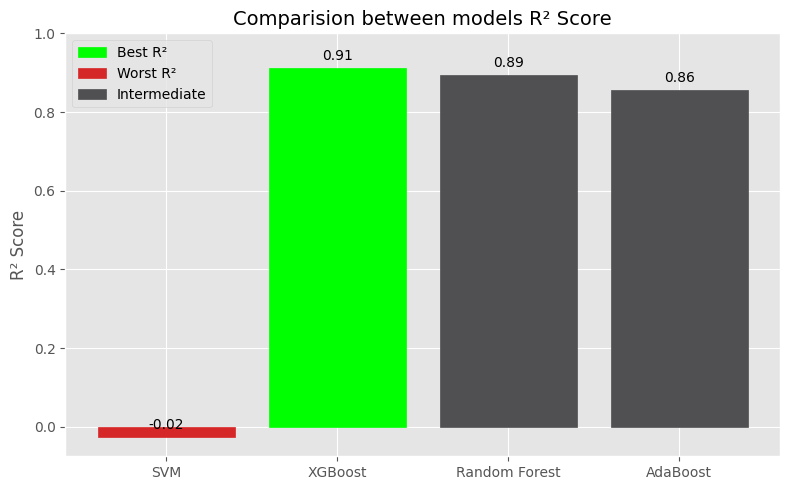

In [61]:
plt.style.use('ggplot')  

fig, ax = plt.subplots(figsize=(8,5))

colors = ['#d62728', "#00ff00", "#505053"]

bars = ax.bar(models, r2_scores, color=colors)

ax.set_title('Comparision between models R² Score', fontsize=14)
ax.set_ylabel('R² Score')

max_idx = r2_scores.index(max(r2_scores))
min_idx = r2_scores.index(min(r2_scores))

for i, bar in enumerate(bars):
    if i == max_idx:
        bar.set_color(colors[1])  
    elif i == min_idx:
        bar.set_color(colors[0]) 
    else:
        bar.set_color(colors[2])  
ax.set_ylim(min(r2_scores)-0.05, 1)

best = mpatches.Patch(color=colors[1], label='Best R²')
worst = mpatches.Patch(color=colors[0], label='Worst R²')
interm = mpatches.Patch(color=colors[2], label='Intermediate')

ax.legend(handles=[best, worst, interm])

for bar in bars:
    altura = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, altura + 0.02,
            f'{altura:.2f}',
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()

MAE

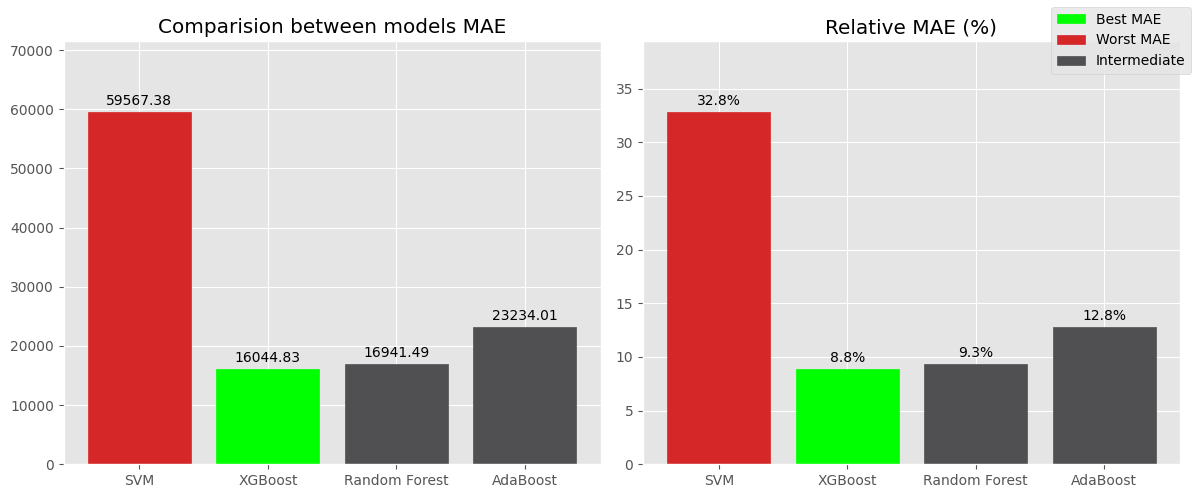

In [ ]:
mean_prices = np.mean(train_target)
mae_rel = [(m / mean_prices) * 100 for m in mae]

max_idx = np.argmax(mae)  
min_idx = np.argmin(mae)  

fig, axs = plt.subplots(1, 2, figsize=(12,5))

bars1 = axs[0].bar(models, mae)

for i, bar in enumerate(bars1):
    if i == min_idx:
        bar.set_color(colors[1])
    elif i == max_idx:
        bar.set_color(colors[0])
    else:
        bar.set_color(colors[2])

axs[0].set_title('Comparision between models MAE')
axs[0].set_ylim(0, max(mae) * 1.2)

for i, v in enumerate(mae):
    axs[0].text(i, v + max(mae)*0.02, f'{v:.2f}', ha='center')

bars2 = axs[1].bar(models, mae_rel)

for i, bar in enumerate(bars2):
    if i == min_idx:
        bar.set_color(colors[1])
    elif i == max_idx:
        bar.set_color(colors[0])
    else:
        bar.set_color(colors[2])

axs[1].set_title('Relative MAE (%)')
axs[1].set_ylim(0, max(mae_rel) * 1.2)

for i, v in enumerate(mae_rel):
    axs[1].text(i, v + max(mae_rel)*0.02, f'{v:.1f}%', ha='center')


best = mpatches.Patch(color=colors[1], label='Best MAE')
worst = mpatches.Patch(color=colors[0], label='Worst MAE')
interm = mpatches.Patch(color=colors[2], label='Intermediate')

fig.legend(handles=[best, worst, interm], loc='upper right', ncol=1)

plt.tight_layout()
plt.show()